In [1]:
# ==========================================================
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import seaborn as sns

In [4]:
# ==========================================================
# Load Dataset
# ==========================================================
from pathlib import Path
DOWNLOADS_DIR = Path.home() / "Downloads"
df = pd.read_csv(DOWNLOADS_DIR/"clean_credit.csv")

In [5]:
print("Shape:", df.shape)

df.head()

Shape: (32411, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32411 entries, 0 to 32410
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32411 non-null  int64  
 1   person_income               32411 non-null  int64  
 2   person_home_ownership       32411 non-null  object 
 3   person_emp_length           32411 non-null  float64
 4   loan_intent                 32411 non-null  object 
 5   loan_grade                  32411 non-null  object 
 6   loan_amnt                   32411 non-null  int64  
 7   loan_int_rate               32411 non-null  float64
 8   loan_status                 32411 non-null  int64  
 9   loan_percent_income         32411 non-null  float64
 10  cb_person_default_on_file   32411 non-null  object 
 11  cb_person_cred_hist_length  32411 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


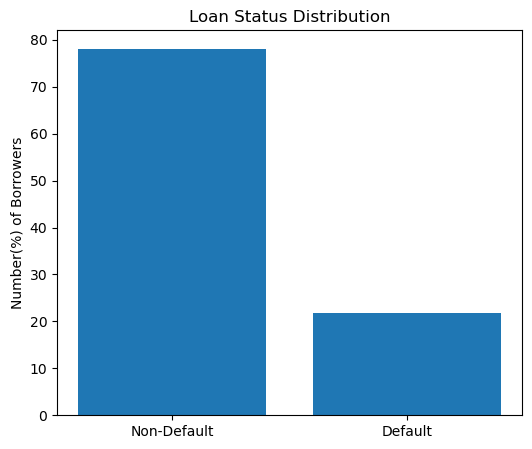

In [7]:
loan_counts = df["loan_status"].value_counts(normalize=True)*100

plt.figure(figsize=(6,5))

plt.bar(
    ["Non-Default","Default"],
    loan_counts.values
)

plt.title("Loan Status Distribution")

plt.ylabel("Number(%) of Borrowers")

plt.show()

In [8]:
df["loan_status"].value_counts()

loan_status
0    25322
1     7089
Name: count, dtype: int64

In [9]:
numerical_columns = [

    "person_age",

    "person_income",

    "person_emp_length",

    "loan_amnt",

    "loan_int_rate",

    "loan_percent_income",

    "cb_person_cred_hist_length"

]

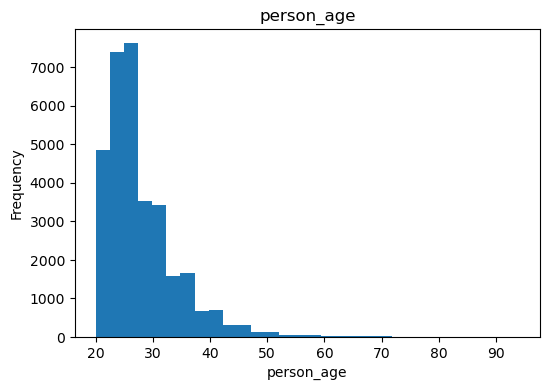

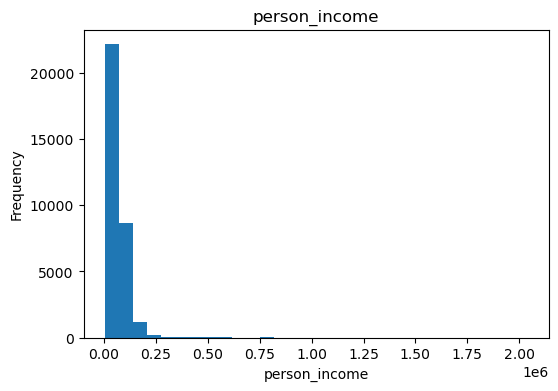

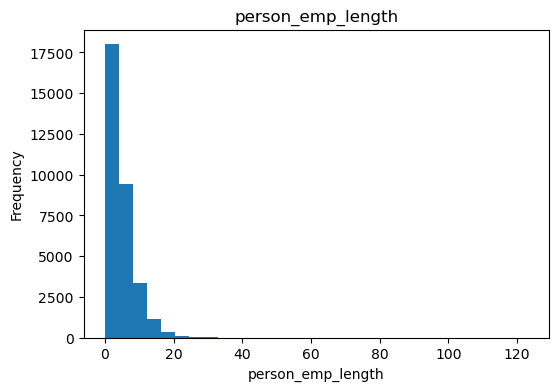

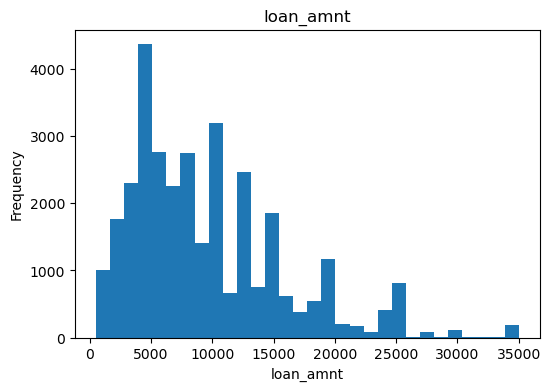

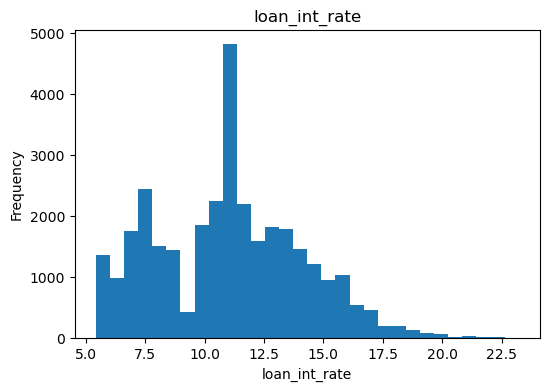

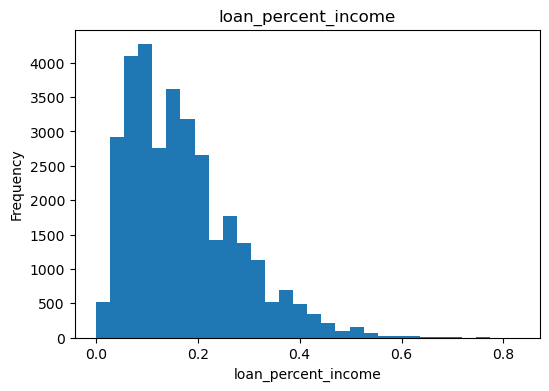

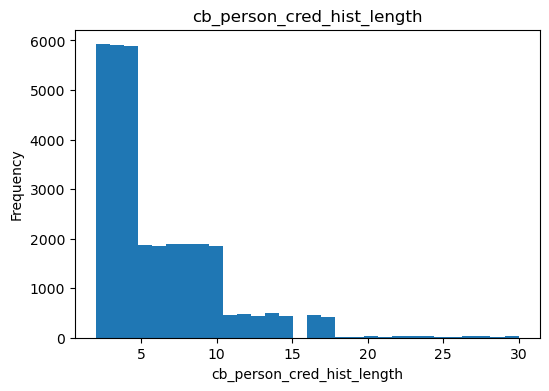

In [10]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    plt.hist(
        df[col],
        bins=30
    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

<Figure size 600x400 with 0 Axes>

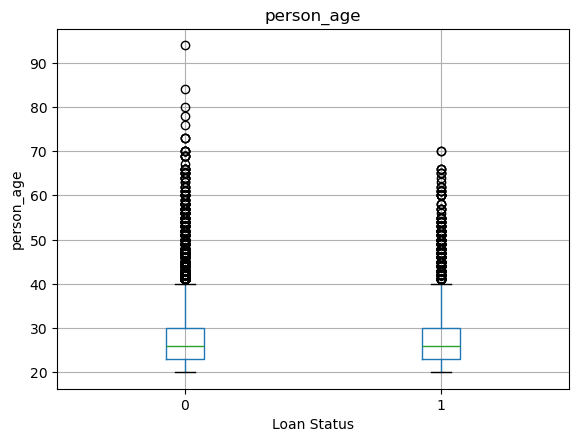

<Figure size 600x400 with 0 Axes>

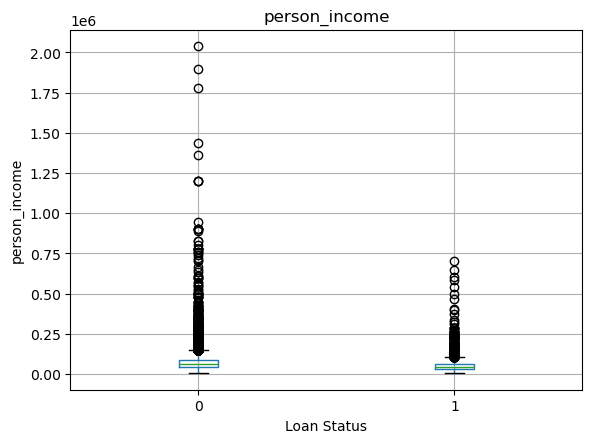

<Figure size 600x400 with 0 Axes>

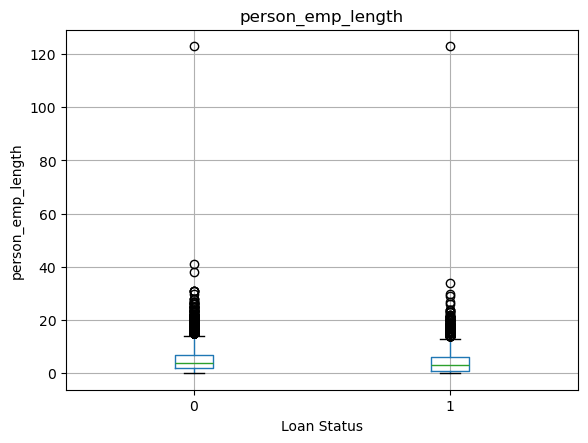

<Figure size 600x400 with 0 Axes>

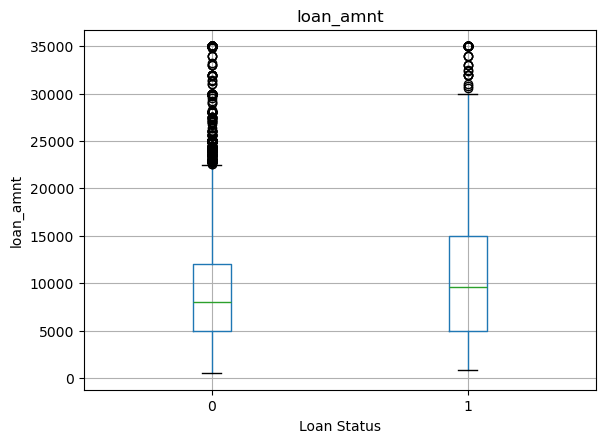

<Figure size 600x400 with 0 Axes>

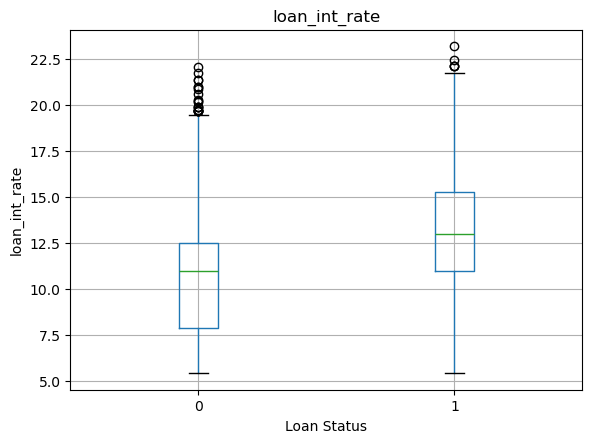

<Figure size 600x400 with 0 Axes>

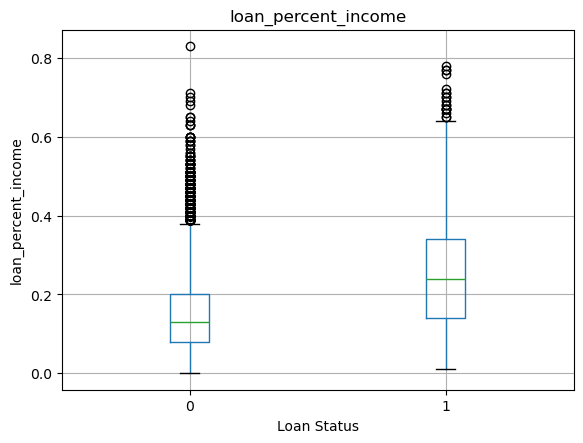

<Figure size 600x400 with 0 Axes>

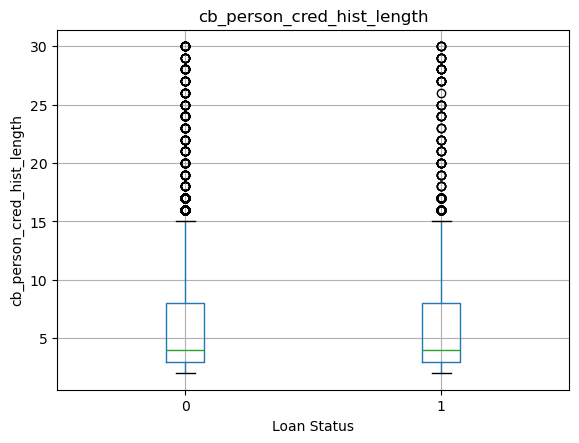

In [11]:
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    df.boxplot(
        column=col,
        by="loan_status"
    )

    plt.title(col)

    plt.suptitle("")

    plt.xlabel("Loan Status")

    plt.ylabel(col)

    plt.show()

In [12]:
categorical_columns = [

    "person_home_ownership",

    "loan_intent",

    "loan_grade",

    "cb_person_default_on_file"

]

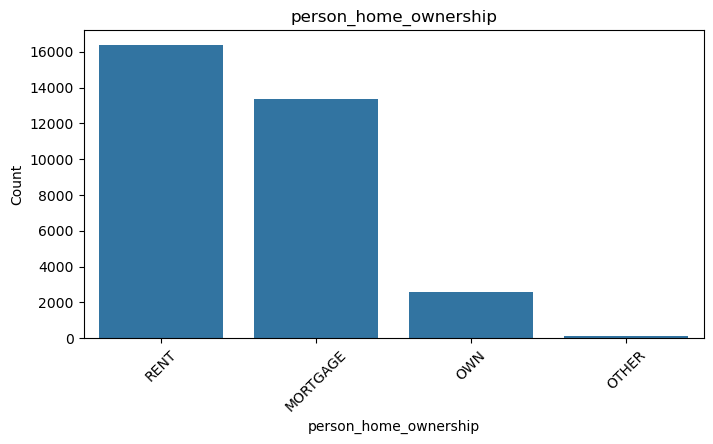

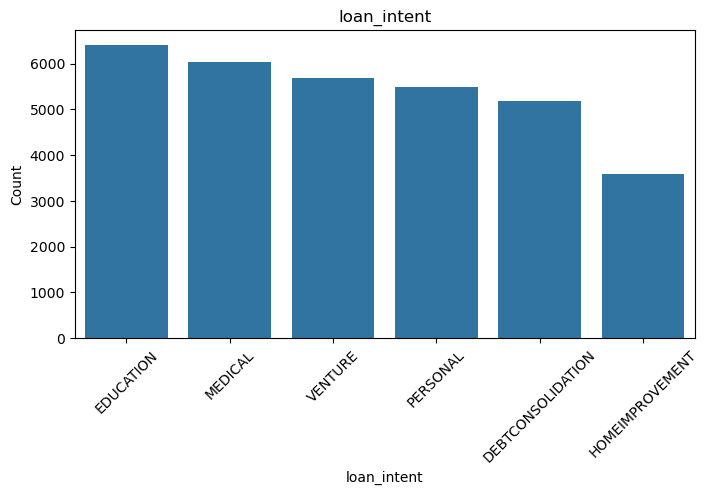

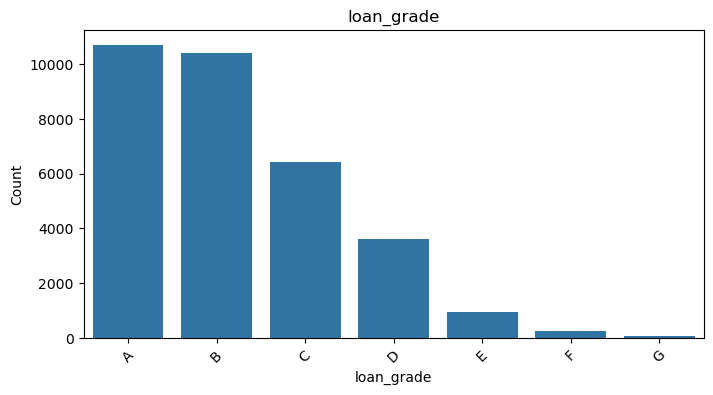

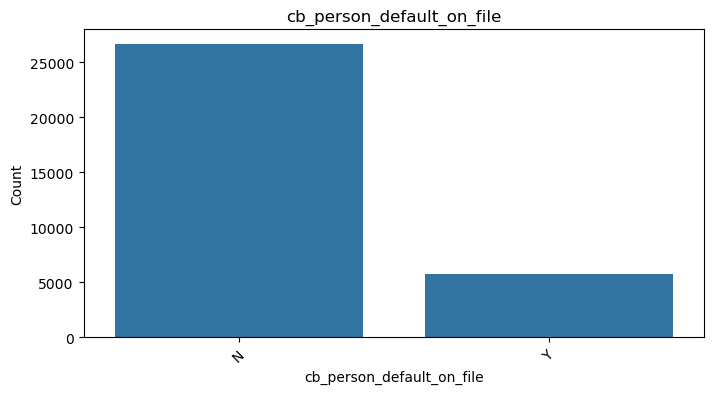

In [13]:
for col in categorical_columns:

    plt.figure(figsize=(8,4))
    sns.countplot(df,x=col,order=df[col].value_counts().index)

       

    plt.title(col)

    plt.xticks(rotation=45)

    plt.ylabel("Count")

    plt.show()

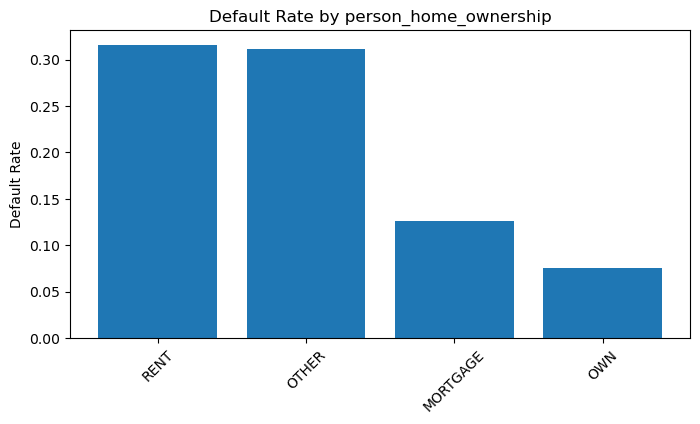

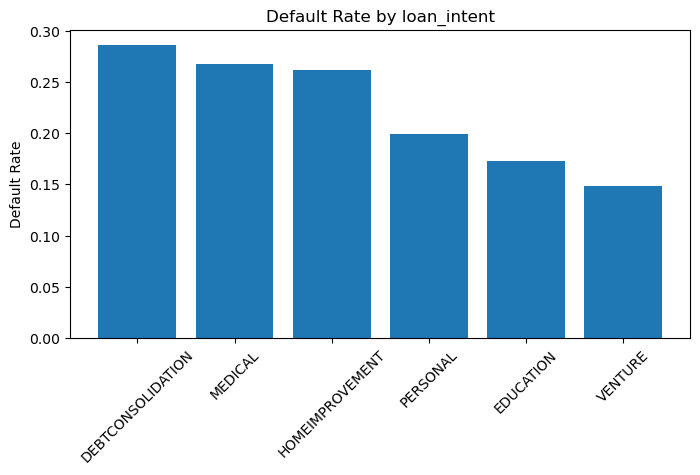

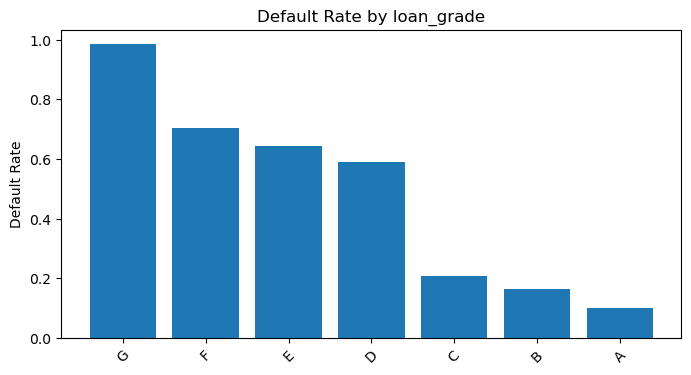

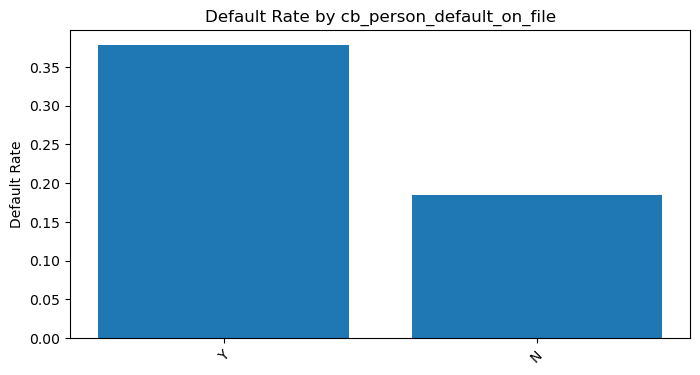

In [14]:
for col in categorical_columns:

    default_rate = (

        df
        .groupby(col)["loan_status"]
        .mean()
        .sort_values(ascending=False)

    )

    plt.figure(figsize=(8,4))

    plt.bar(
        default_rate.index.astype(str),
        default_rate.values
    )

    plt.title(f"Default Rate by {col}")

    plt.ylabel("Default Rate")

    plt.xticks(rotation=45)

    plt.show()

In [15]:
default_rate

cb_person_default_on_file
Y    0.378709
N    0.184363
Name: loan_status, dtype: float64

In [16]:
corr=df.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Matrix')

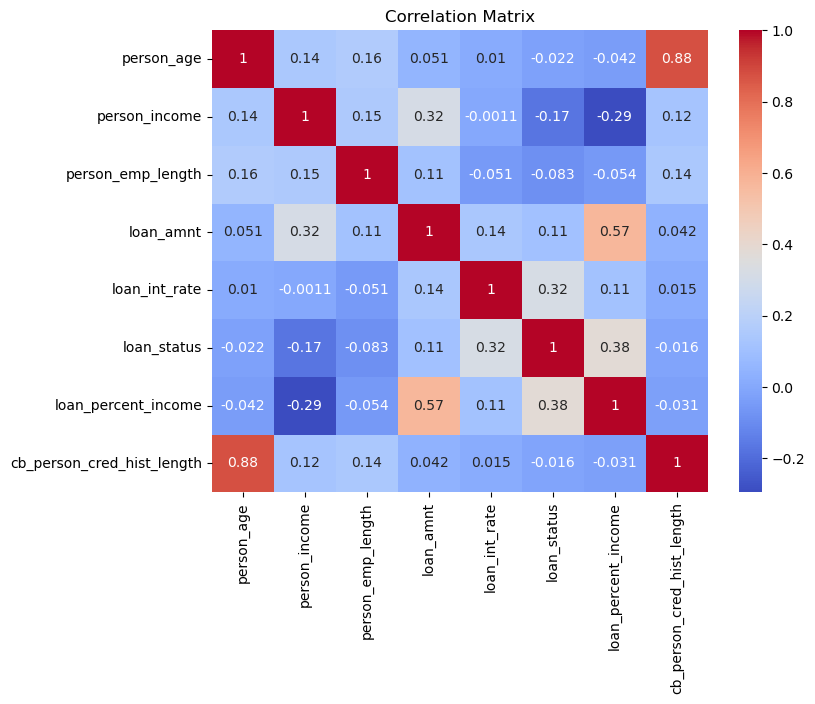

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

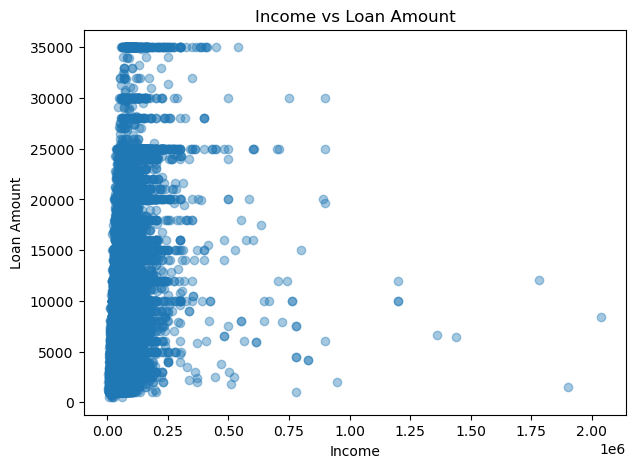

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(

    df["person_income"],

    df["loan_amnt"],

    alpha=0.4

)

plt.xlabel("Income")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

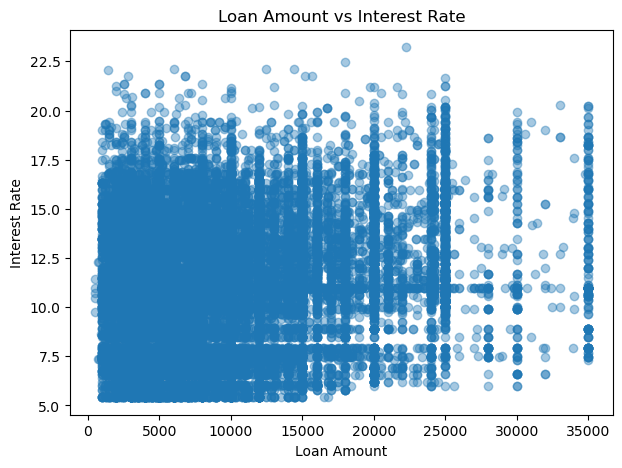

In [19]:
plt.figure(figsize=(7,5))

plt.scatter(

    df["loan_amnt"],

    df["loan_int_rate"],

    alpha=0.4

)

plt.xlabel("Loan Amount")

plt.ylabel("Interest Rate")

plt.title("Loan Amount vs Interest Rate")

plt.show()

In [20]:
target_corr = (

    corr["loan_status"]

    .sort_values()

)

target_corr

person_income                -0.169284
person_emp_length            -0.082503
person_age                   -0.021808
cb_person_cred_hist_length   -0.016473
loan_amnt                     0.105771
loan_int_rate                 0.320117
loan_percent_income           0.379704
loan_status                   1.000000
Name: loan_status, dtype: float64